In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('/home/arya/Documents/Winter 2026/ESS_469/MLGEO-2026/data/assignments/06.PCA/Ranu/Alaska.csv')


In [25]:
print(df.head())
print("/n")
print(df.columns)

                    rgi_id  o1region o2region        glims_id  anlys_id  \
0  RGI2000-v7.0-G-01-00001         1    01-01  G204091E67414N    392889   
1  RGI2000-v7.0-G-01-00002         1    01-01  G204121E67419N    392890   
2  RGI2000-v7.0-G-01-00003         1    01-01  G204471E67431N    392897   
3  RGI2000-v7.0-G-01-00004         1    01-01  G204497E67431N    392899   
4  RGI2000-v7.0-G-01-00005         1    01-01  G204521E67429N    392901   

   subm_id             src_date      cenlon     cenlat  utm_zone  ...  \
0      624  2008-09-02T00:00:00 -155.909404  67.413726         5  ...   
1      624  2008-09-02T00:00:00 -155.879114  67.419232         5  ...   
2      624  2008-09-02T00:00:00 -155.530786  67.431484         5  ...   
3      624  2008-09-02T00:00:00 -155.501948  67.430514         5  ...   
4      624  2008-09-02T00:00:00 -155.478173  67.432873         5  ...   

     termlat     zmin_m     zmax_m     zmed_m    zmean_m  slope_deg  \
0  67.416034  1485.3176  1693.6235  154

In [ ]:
# Need to filter only for numerical values for PCA and correlation matrix to be created 

numerical_df = df.drop(columns=['rgi_id', 'o1region', 'o2region', 'glims_id', 'anlys_id', 'subm_id', 'src_date', 'cenlon', 'cenlat', 'utm_zone', 'primeclass', 'conn_lvl', 'surge_type', 'term_type', 'glac_name', 'is_rgi6', 'termlon', 'termlat', 'dem_source', 'aspect_sec'])

print(numerical_df.columns)


Index(['area_km2', 'zmin_m', 'zmax_m', 'zmed_m', 'zmean_m', 'slope_deg',
       'aspect_deg', 'aspect_sec', 'lmax_m'],
      dtype='str')


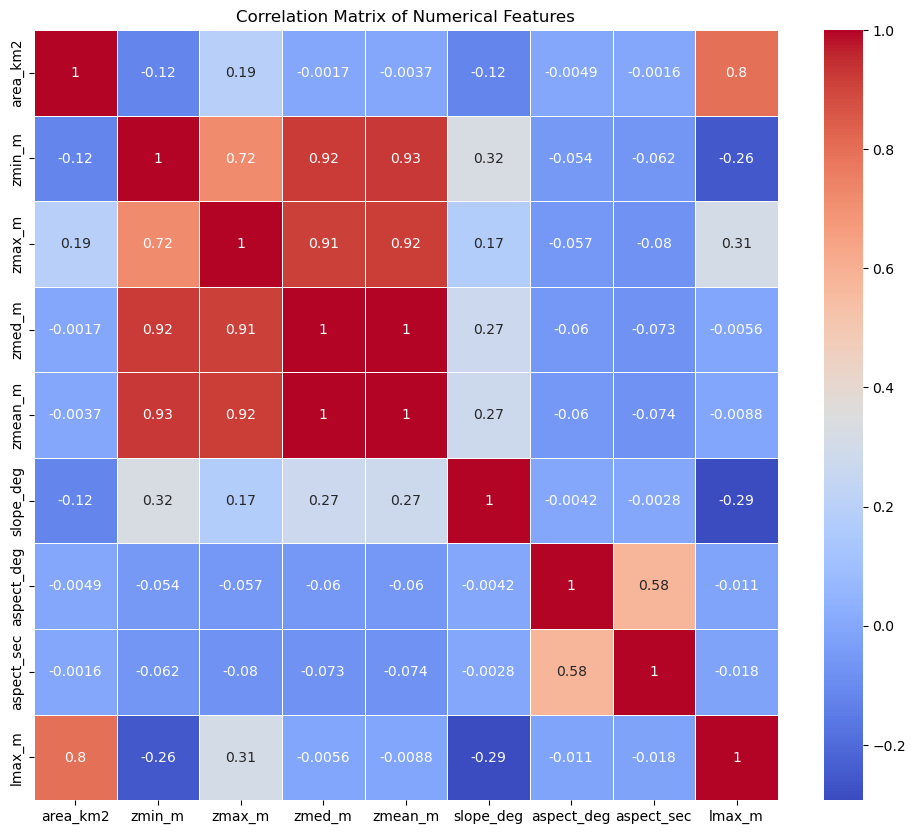

In [27]:
# From here conduct correlation and PCA analysis using the df_numerical dataframe 
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=
0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

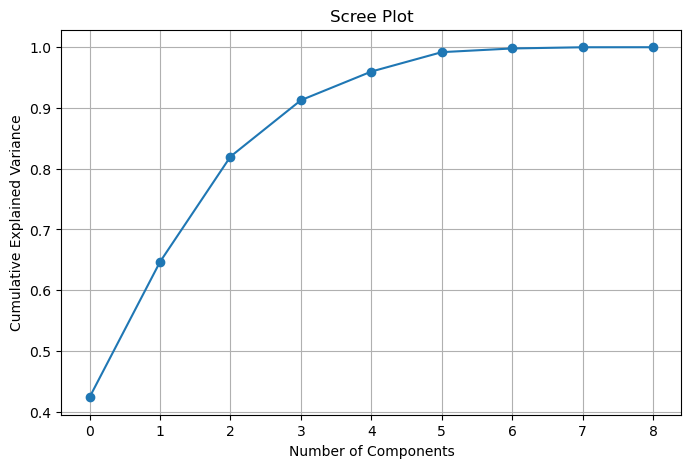

In [28]:
#Apply PCA and produce scree plot to determine how many components to keep
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_df)
pca = PCA()
pca.fit(scaled_data)
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [33]:
# From the screen plot, we see that the first 5 components explain most of the variance in the data, so we will keep those for further analysis
pca = PCA(n_components=5)
pca_data = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(data=pca_data, columns=[f'PC{i+1}' for i in range(5)])
print(pca_df.head())


        PC1       PC2       PC3       PC4       PC5
0 -0.144463 -0.043650  0.008015 -0.910600 -1.711568
1 -0.987088 -0.249181 -0.042173 -0.466864 -1.738924
2 -0.265274 -0.039700 -1.877491  0.047055  0.140060
3 -1.370609  0.106544 -1.559336 -1.253584  0.279623
4 -1.437007  0.074029  1.526977 -0.771468  0.361822


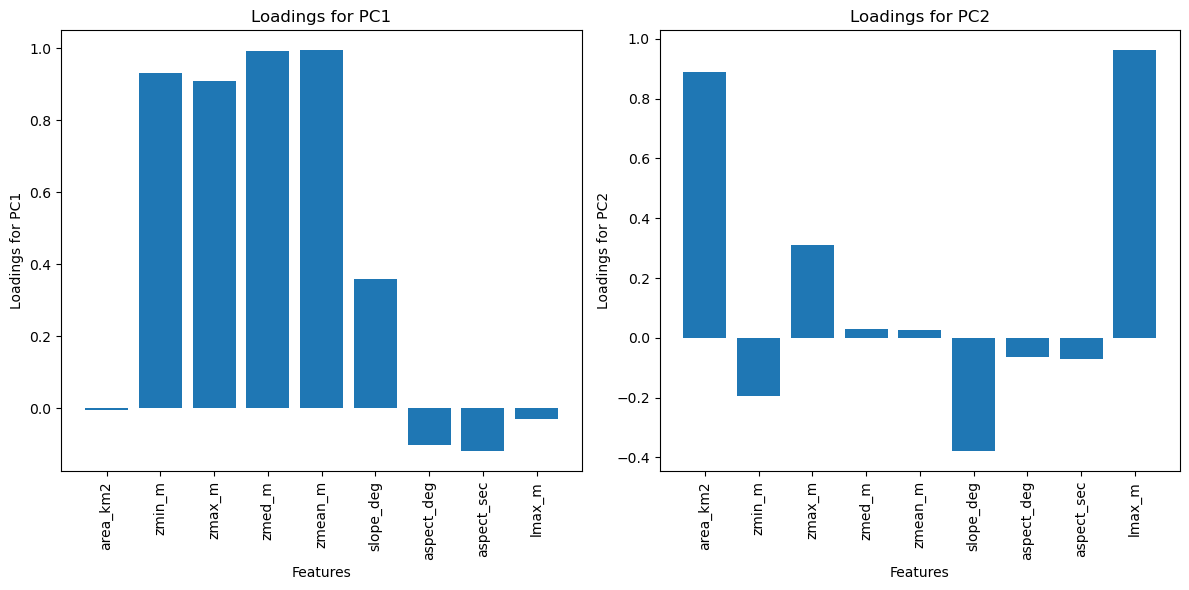

In [36]:
feature_names = numerical_df.columns

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(12, 6))

# PC1
plt.subplot(1, 2, 1)
plt.bar(range(len(loadings)), loadings[:, 0])
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.xlabel('Features')
plt.ylabel('Loadings for PC1')
plt.title('Loadings for PC1')

# PC2
plt.subplot(1, 2, 2)
plt.bar(range(len(loadings)), loadings[:, 1])
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.xlabel('Features')
plt.ylabel('Loadings for PC2')
plt.title('Loadings for PC2')

plt.tight_layout()
plt.show()